# Fraud Investigation Platform - Graph Intelligence Layer


**Stack:** Python · pandas · **NetworkX** · scikit-learn · SQLite · Gemini · matplotlib

---

## Architecture

```
Transactions ─▶ Behavioural features ─┐
      │                               ├─▶ Fraud model ─▶ ML risk ─┐
      ▼                               │                            │
 Entity graph ─▶ Graph features ──────┘                            │
      │                                                            ▼
      ├────────────────────────▶ Network risk ──────────▶ Alert scoring
      │                                                            │
      │                          Behavioural risk ─────────────────┤
      │                                                            ▼
      └──────────────▶ Ring detection              Alert prioritisation
                              │                                    │
                              └──────────▶ Case management ◀───────┘
                                                   │
                                          Evidence pack (deterministic)
                                                   │
                                          Gemini narration ─▶ Analyst
```


---
## Setup


In [ ]:
!pip install faker scikit-learn pandas numpy matplotlib networkx google-generativeai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx                # the transaction graph
import sqlite3, json, random, logging, itertools
import datetime as dt
from faker import Faker
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, precision_recall_curve)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
fake = Faker(); Faker.seed(SEED)

In [ ]:
logger = logging.getLogger("fraud_graph")
logger.setLevel(logging.INFO); logger.handlers.clear(); logger.propagate = False
_f = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler("investigation.log"); _fh.setFormatter(_f); logger.addHandler(_fh)
_ch = logging.StreamHandler(); _ch.setFormatter(_f); logger.addHandler(_ch)
logger.info("Investigation platform logging initialised")

2026-09-18 18:30:05,107 | INFO | Investigation platform logging initialised


In [ ]:
from google.colab import userdata
import google.generativeai as genai

try:
    genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
    gemini_model = genai.GenerativeModel('gemini-2.5-flash-lite')
    GEMINI_READY = True
    print("\u2713 Gemini configured")
except Exception as e:
    gemini_model, GEMINI_READY = None, False
    print("Gemini unavailable — the deterministic brief will still work:", e)

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✓ Gemini configured


---
## Extended Entity Model


In [ ]:
N_CUST, N_MERCH, N_DEV = 400, 60, 500
HOME = ["US","GB","IN","DE","SG"]

customers = pd.DataFrame({
    "customer_id":      [f"C{1000+i}" for i in range(N_CUST)],
    "name":             [fake.name() for _ in range(N_CUST)],
    "home_country":     np.random.choice(HOME, N_CUST),
    "account_age_days": np.random.randint(1, 2000, N_CUST),
})
merchants = pd.DataFrame({
    "merchant_id":        [f"M{200+i}" for i in range(N_MERCH)],
    "category":           np.random.choice(["grocery","electronics","travel",
                                            "gaming","crypto","fashion"], N_MERCH),
    "merchant_risk_tier": np.random.choice([1,2,3], N_MERCH, p=[.6,.3,.1]),
})
devices = pd.DataFrame({
    "device_id":   [f"D{3000+i}" for i in range(N_DEV)],
    "device_type": np.random.choice(["ios","android","web"], N_DEV),
})

# each customer legitimately owns 1-2 devices
cust_devices = {c: list(np.random.choice(devices["device_id"],
                                         np.random.choice([1,2], p=[.7,.3]), replace=False))
                for c in customers["customer_id"]}

print(f"\u2713 {N_CUST} customers | {N_MERCH} merchants | {N_DEV} devices")
print("   Devices are the new entity — they are what makes a graph meaningful.")

✓ 400 customers | 60 merchants | 500 devices
   Devices are the new entity — they are what makes a graph meaningful.


---
## Fraud Ring Injection

In [ ]:
N_RINGS = 12
ring_members, ring_devices, ring_merchants = {}, {}, {}
all_ring_customers = set()

pool = list(customers["customer_id"]); random.shuffle(pool)
idx = 0
for r in range(N_RINGS):
    size = np.random.randint(4, 9)
    members = pool[idx:idx+size]; idx += size
    if len(members) < 4:
        break
    ring_members[r]   = members
    ring_devices[r]   = [f"D{3000+N_DEV+r}"]                                  # one shared device
    ring_merchants[r] = list(np.random.choice(merchants["merchant_id"], 2, replace=False))
    all_ring_customers.update(members)

# register the ring devices so they exist as real entities
devices = pd.concat([devices, pd.DataFrame({
    "device_id":   [d for v in ring_devices.values() for d in v],
    "device_type": "android"})], ignore_index=True)

print(f"\u2713 {len(ring_members)} fraud rings seeded | "
      f"{len(all_ring_customers)} customers involved")
print("   Each ring shares ONE device. Members transact normally otherwise.")
for r in list(ring_members)[:3]:
    print(f"   ring {r}: {len(ring_members[r])} customers -> device {ring_devices[r][0]}")

✓ 12 fraud rings seeded | 81 customers involved
   Each ring shares ONE device. Members transact normally otherwise.
   ring 0: 6 customers -> device D3500
   ring 1: 6 customers -> device D3501
   ring 2: 6 customers -> device D3502


---
## Transaction Generation & Dual Fraud Labels


In [ ]:
N_TXN_NORMAL = 30000
start = dt.datetime(2024, 1, 1)
cust_base = {c: np.random.randint(0, 60*24*90) for c in customers["customer_id"]}
cinfo = customers.set_index("customer_id").to_dict("index")
rows = []

# ---------- normal population ----------
for _ in range(N_TXN_NORMAL):
    c = np.random.choice(customers["customer_id"])
    offset = (cust_base[c] + np.random.randint(0, 180)) if np.random.rand() < 0.6 \
             else (cust_base[c] + np.random.randint(0, 60*24*60))
    rows.append({
        "customer_id": c,
        "merchant_id": np.random.choice(merchants["merchant_id"]),
        "device_id":   np.random.choice(cust_devices[c]),
        "timestamp":   start + dt.timedelta(minutes=int(offset)),
        "amount":      round(float(np.random.exponential(80) + 1), 2),
        "txn_country": np.random.choice(HOME + ["NG","RU","BR"],
                                        p=[.18,.18,.18,.18,.16,.04,.04,.04]),
        "status":      np.random.choice(["success","failed"], p=[.94,.06]),
        "ring_id":     -1,
    })

# ---------- ring activity: deliberately UNREMARKABLE per transaction ----------
for r, members in ring_members.items():
    dev = ring_devices[r][0]
    for c in members:
        for _ in range(np.random.randint(12, 25)):
            rows.append({
                "customer_id": c,
                "merchant_id": np.random.choice(ring_merchants[r]),
                "device_id":   dev,                       # <- the only tell is the shared device
                "timestamp":   start + dt.timedelta(
                                   minutes=int(cust_base[c] + np.random.randint(0, 60*24*60))),
                "amount":      round(float(np.random.exponential(80) + 1), 2),  # normal amount
                "txn_country": cinfo[c]["home_country"],                        # domestic
                "status":      "success",                                       # no failures
                "ring_id":     r,
            })

txn = pd.DataFrame(rows)
txn["transaction_id"] = [f"T{900000+i}" for i in range(len(txn))]
txn = txn.merge(customers, on="customer_id") \
         .merge(merchants[["merchant_id","merchant_risk_tier"]], on="merchant_id")
txn = txn.sort_values(["customer_id","timestamp"]).reset_index(drop=True)

# rolling velocity, needed by the behavioural fraud pattern below
def _vel(g):
    g = g.set_index("timestamp"); g["v"] = g["amount"].rolling("1h").count(); return g.reset_index()
txn = txn.groupby("customer_id", group_keys=False)[txn.columns.tolist()].apply(_vel)

print(f"\u2713 {len(txn):,} transactions "
      f"({(txn['ring_id']>=0).sum():,} from rings, {(txn['ring_id']<0).sum():,} normal)")

✓ 31,449 transactions (1,449 from rings, 30,000 normal)


In [ ]:
hour       = txn["timestamp"].dt.hour
is_night   = ((hour < 6) | (hour >= 23)).astype(int)
is_foreign = (txn["txn_country"] != txn["home_country"]).astype(int)
is_new     = (txn["account_age_days"] < 60).astype(int)
high_amt   = (txn["amount"] > 250).astype(int)
burst      = (txn["v"] >= 5).astype(int)

# --- Pattern A: classic behavioural fraud (detectable from the transaction itself) ---
z = (-6.5 + 2.2*is_foreign + 1.8*is_new + 1.0*is_night
     + 1.1*(txn["merchant_risk_tier"]-1) + 2.4*high_amt
     + 0.9*(txn["status"]=="failed").astype(int) + 2.0*burst
     + 1.5*(is_foreign*high_amt))
behavioural_fraud = (np.random.rand(len(txn)) < 1/(1+np.exp(-z))).astype(int)

# --- Pattern B: ring fraud (NOT detectable from the transaction itself) ---
ring_fraud = ((txn["ring_id"] >= 0) & (np.random.rand(len(txn)) < 0.70)).astype(int)

txn["is_fraud"]   = np.maximum(behavioural_fraud, ring_fraud)
txn["fraud_type"] = np.where(ring_fraud == 1, "ring",
                    np.where(behavioural_fraud == 1, "behavioural", "none"))

logger.info(f"Labelled {len(txn)} transactions | fraud rate {txn['is_fraud'].mean():.3f}")
print(f"Overall fraud rate: {txn['is_fraud'].mean():.1%}\n")
print(txn["fraud_type"].value_counts().to_frame("transactions").to_string())

# prove the ring fraud is behaviourally invisible
print("\nAre ring transactions distinguishable on their own?")
comp = txn.groupby("fraud_type")[["amount"]].mean().round(1)
comp["foreign_%"]  = (txn.assign(f=is_foreign).groupby("fraud_type")["f"].mean()*100).round(1)
comp["night_%"]    = (txn.assign(n=is_night).groupby("fraud_type")["n"].mean()*100).round(1)
comp["velocity"]   = txn.groupby("fraud_type")["v"].mean().round(2)
print(comp.to_string())

2026-09-18 18:30:33,036 | INFO | Labelled 31449 transactions | fraud rate 0.169


Overall fraud rate: 16.9%

             transactions
fraud_type               
none                26137
behavioural          4298
ring                 1014

Are ring transactions distinguishable on their own?
             amount  foreign_%  night_%  velocity
fraud_type                                       
behavioural   121.6       96.6     45.6     11.84
none           74.0       79.2     27.9      7.69
ring           82.6        0.0     29.2      1.09


---
## Behavioural Features (the baseline)


In [ ]:
def engineer(g):
    g = g.sort_values("timestamp").set_index("timestamp")
    g["txn_velocity_1h"] = g["amount"].rolling("1h").count()
    g["cust_avg_amount"] = g["amount"].expanding().mean().shift(1)   # shift => no leakage
    return g.reset_index()

f = txn.groupby("customer_id", group_keys=False)[txn.columns.tolist()].apply(engineer)
f["cust_avg_amount"]  = f["cust_avg_amount"].fillna(f["amount"].mean())
f["amount_deviation"] = f["amount"] - f["cust_avg_amount"]
f["hour"]             = f["timestamp"].dt.hour
f["is_night"]         = ((f["hour"] < 6) | (f["hour"] >= 23)).astype(int)
f["is_foreign"]       = (f["txn_country"] != f["home_country"]).astype(int)
f["is_new_account"]   = (f["account_age_days"] < 60).astype(int)
f["is_failed"]        = (f["status"] == "failed").astype(int)

BASE_FEATURES = ["amount","amount_deviation","txn_velocity_1h","hour","is_night",
                 "is_foreign","is_new_account","merchant_risk_tier","is_failed"]

print(f"\u2713 {len(BASE_FEATURES)} behavioural features — the existing pipeline's view of the world")
print("  ", ", ".join(BASE_FEATURES))

✓ 9 behavioural features — the existing pipeline's view of the world
   amount, amount_deviation, txn_velocity_1h, hour, is_night, is_foreign, is_new_account, merchant_risk_tier, is_failed


---
## Transaction Graph


In [ ]:
G = nx.Graph()
for c in customers["customer_id"]: G.add_node(c, kind="customer")
for m in merchants["merchant_id"]: G.add_node(m, kind="merchant")
for d in devices["device_id"]:     G.add_node(d, kind="device")

for r in f.itertuples():
    G.add_edge(r.customer_id, r.device_id,   kind="uses")
    G.add_edge(r.customer_id, r.merchant_id, kind="transacts_at")

logger.info(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"\u2713 Entity graph: {G.number_of_nodes():,} nodes | {G.number_of_edges():,} edges")
kinds = pd.Series([d["kind"] for _, d in G.nodes(data=True)]).value_counts()
print(kinds.to_frame("nodes").to_string())

2026-09-18 18:30:34,854 | INFO | Graph built: 972 nodes, 17765 edges


✓ Entity graph: 972 nodes | 17,765 edges
          nodes
device      512
customer    400
merchant     60


In [ ]:
cust_graph = nx.Graph()
cust_graph.add_nodes_from(customers["customer_id"])

for dev, grp in f.groupby("device_id"):
    shared = grp["customer_id"].unique()
    if 1 < len(shared) <= 30:                       # cap guards against hub devices
        for a, b in itertools.combinations(shared, 2):
            cust_graph.add_edge(a, b, via=dev)

component_size = {}
for comp in nx.connected_components(cust_graph):
    for node in comp:
        component_size[node] = len(comp)
degree = dict(cust_graph.degree())

print(f"\u2713 Customer projection: {cust_graph.number_of_nodes()} nodes | "
      f"{cust_graph.number_of_edges()} edges")
print(f"   Largest connected component: {max(component_size.values())} customers")
print(f"   Customers with >=3 device-neighbours: {sum(1 for v in degree.values() if v>=3)}")

✓ Customer projection: 400 nodes | 507 edges
   Largest connected component: 169 customers
   Customers with >=3 device-neighbours: 131


---
## Graph Feature Engineering

In [ ]:
# temporal split — everything "historical" is computed ONLY on the training period
f = f.sort_values("timestamp").reset_index(drop=True)
split_ts   = f["timestamp"].quantile(0.70)
train_mask = f["timestamp"] <= split_ts
history    = f[train_mask]

# structural features (no labels involved)
dev_customers = f.groupby("device_id")["customer_id"].nunique().to_dict()
mer_customers = f.groupby("merchant_id")["customer_id"].nunique().to_dict()

# historical-outcome features (labels, but ONLY from the past)
dev_fraud_n    = history.groupby("device_id")["is_fraud"].sum().to_dict()
dev_txn_n      = history.groupby("device_id")["is_fraud"].count().to_dict()
mer_fraud_rate = history.groupby("merchant_id")["is_fraud"].mean().to_dict()

f["g_device_shared_customers"]   = f["device_id"].map(dev_customers).fillna(1)
f["g_merchant_customer_count"]   = f["merchant_id"].map(mer_customers).fillna(1)
f["g_device_hist_fraud_count"]   = f["device_id"].map(dev_fraud_n).fillna(0)
f["g_device_hist_fraud_rate"]    = (f["device_id"].map(dev_fraud_n).fillna(0) /
                                    f["device_id"].map(dev_txn_n).fillna(1)).fillna(0)
f["g_merchant_hist_fraud_rate"]  = f["merchant_id"].map(mer_fraud_rate).fillna(0)
f["g_cust_component_size"]       = f["customer_id"].map(component_size).fillna(1)
f["g_cust_degree"]               = f["customer_id"].map(degree).fillna(0)

GRAPH_FEATURES = ["g_device_shared_customers","g_merchant_customer_count",
                  "g_device_hist_fraud_count","g_device_hist_fraud_rate",
                  "g_merchant_hist_fraud_rate","g_cust_component_size","g_cust_degree"]

print(f"\u2713 {len(GRAPH_FEATURES)} graph features")
print(f"   Temporal cut at {split_ts:%Y-%m-%d} — history uses train period only")
f[["transaction_id"]+GRAPH_FEATURES].head(3)

✓ 7 graph features
   Temporal cut at 2024-03-14 — history uses train period only


,transaction_id,g_device_shared_customers,g_merchant_customer_count,g_device_hist_fraud_count,g_device_hist_fraud_rate,g_merchant_hist_fraud_rate,g_cust_component_size,g_cust_degree
0,T921209,3,282,20.0,0.157480,0.163683,169,3
1,T917424,2,279,11.0,0.127907,0.098413,169,3
2,T917438,3,292,20.0,0.157480,0.115068,169,3


---
## The Headline Experiment


In [ ]:
train, test = f[train_mask], f[~train_mask]
print(f"train {len(train):,} | test {len(test):,} | test fraud rate {test['is_fraud'].mean():.1%}\n")

def run_model(features, label):
    m = RandomForestClassifier(n_estimators=300, max_depth=14,
                               class_weight="balanced", random_state=SEED, n_jobs=-1)
    m.fit(train[features], train["is_fraud"])
    p = m.predict_proba(test[features])[:, 1]

    k       = int(len(test) * 0.10)
    top_k   = test.assign(p=p).nlargest(k, "p")
    rings   = test[test["fraud_type"] == "ring"]

    res = {
        "ROC-AUC":          roc_auc_score(test["is_fraud"], p),
        "PR-AUC":           average_precision_score(test["is_fraud"], p),
        "Recall@10%":       top_k["is_fraud"].sum() / test["is_fraud"].sum(),
        "RingRecall@10%":   (top_k["fraud_type"] == "ring").sum() / max(len(rings), 1),
    }
    logger.info(f"{label}: " + " ".join(f"{k}={v:.4f}" for k, v in res.items()))
    return m, p, res

model_base,  p_base,  res_base  = run_model(BASE_FEATURES, "baseline")
model_graph, p_graph, res_graph = run_model(BASE_FEATURES + GRAPH_FEATURES, "graph-enhanced")

comparison = pd.DataFrame({"Baseline": res_base, "Graph-enhanced": res_graph})
comparison["Delta"] = comparison["Graph-enhanced"] - comparison["Baseline"]
comparison["Lift %"] = (comparison["Delta"] / comparison["Baseline"] * 100).round(1)
print(comparison.round(4).to_string())

train 22,016 | test 9,433 | test fraud rate 14.4%



2026-09-18 18:30:46,251 | INFO | baseline: ROC-AUC=0.8010 PR-AUC=0.4369 Recall@10%=0.3206 RingRecall@10%=0.2808
2026-09-18 18:30:57,146 | INFO | graph-enhanced: ROC-AUC=0.8618 PR-AUC=0.5512 Recall@10%=0.4429 RingRecall@10%=0.9093


                Baseline  Graph-enhanced   Delta  Lift %
ROC-AUC           0.8010          0.8618  0.0608     7.6
PR-AUC            0.4369          0.5512  0.1143    26.2
Recall@10%        0.3206          0.4429  0.1223    38.2
RingRecall@10%    0.2808          0.9093  0.6285   223.8


In [ ]:
imp = pd.DataFrame({
    "feature":    BASE_FEATURES + GRAPH_FEATURES,
    "importance": model_graph.feature_importances_,
})
imp["type"] = np.where(imp["feature"].str.startswith("g_"), "graph", "behavioural")
imp = imp.sort_values("importance", ascending=False)

print(imp.head(10).to_string(index=False))
print(f"\nTotal importance held by graph features: "
      f"{imp[imp['type']=='graph']['importance'].sum():.1%}")

                   feature  importance        type
           txn_velocity_1h    0.137487 behavioural
  g_device_hist_fraud_rate    0.136481       graph
                    amount    0.134318 behavioural
          amount_deviation    0.107995 behavioural
g_merchant_hist_fraud_rate    0.091902       graph
                is_foreign    0.071945 behavioural
 g_device_hist_fraud_count    0.052502       graph
        merchant_risk_tier    0.051357 behavioural
                      hour    0.048396 behavioural
 g_device_shared_customers    0.048316       graph

Total importance held by graph features: 40.0%


---
## Fraud Ring Detection

In [ ]:
suspicious = f[f["g_device_shared_customers"] >= 4]

detected = suspicious.groupby("device_id").agg(
    customers = ("customer_id", "nunique"),
    txns      = ("transaction_id", "count"),
    fraud     = ("is_fraud", "sum"),
    value     = ("amount", "sum"),
).reset_index()
detected["fraud_density"] = (detected["fraud"] / detected["txns"]).round(3)
detected = detected.sort_values("fraud_density", ascending=False)

true_ring_devices = {d for v in ring_devices.values() for d in v}
top_n   = len(true_ring_devices)
caught  = len(set(detected.head(top_n)["device_id"]) & true_ring_devices)

print(f"Detected {caught}/{top_n} seeded rings in the top {top_n} devices by fraud density\n")
print(detected.head(8).to_string(index=False))
logger.info(f"Ring detection: {caught}/{top_n} seeded rings recovered")

2026-09-18 18:30:57,293 | INFO | Ring detection: 12/12 seeded rings recovered


Detected 12/12 seeded rings in the top 12 devices by fraud density

device_id  customers  txns  fraud    value  fraud_density
    D3504          7   121     96 10408.35          0.793
    D3502          6    99     76  8659.88          0.768
    D3506          7   113     84  9622.71          0.743
    D3508          6   108     79  7056.48          0.731
    D3505          8   137     99 10657.50          0.723
    D3501          6    97     70  8405.33          0.722
    D3500          6   115     80 10338.35          0.696
    D3507          5    99     68  8246.94          0.687


---
## Alert Intelligence


In [ ]:
scored = test.assign(ml_risk=p_graph).copy()

# behavioural component
scored["behaviour_risk"] = (
      (scored["amount_deviation"] > scored["amount_deviation"].quantile(.90)).astype(int) * 0.4
    + (scored["txn_velocity_1h"] >= 5).astype(int) * 0.3
    +  scored["is_foreign"] * 0.3)

# network component
nmax = scored["g_device_shared_customers"].max()
scored["network_risk"] = (0.5 * scored["g_device_shared_customers"] / nmax
                        + 0.5 * scored["g_device_hist_fraud_rate"]).clip(0, 1)

# composite
scored["alert_score"] = (0.5*scored["ml_risk"]
                       + 0.2*scored["behaviour_risk"]
                       + 0.3*scored["network_risk"]).round(4)
scored["severity"] = pd.cut(scored["alert_score"], [-.01,.3,.5,.7,1.01],
                            labels=["Low","Medium","High","Critical"])

alerts = scored[scored["alert_score"] > 0.5].copy()
print(f"Alerts raised: {len(alerts):,} of {len(scored):,} transactions")
print(f"Alert precision (share truly fraudulent): {alerts['is_fraud'].mean():.1%}\n")
print(alerts["severity"].value_counts().to_frame("alerts").to_string())
logger.info(f"{len(alerts)} alerts raised | precision {alerts['is_fraud'].mean():.3f}")

2026-09-18 18:30:57,340 | INFO | 944 alerts raised | precision 0.648


Alerts raised: 944 of 9,433 transactions
Alert precision (share truly fraudulent): 64.8%

          alerts
severity        
High         856
Critical      88
Medium         0
Low            0


---
## Case Management



In [ ]:
case_rows = []
for dev, grp in alerts.groupby("device_id"):
    if grp["customer_id"].nunique() >= 2 or len(grp) >= 5:
        case_rows.append({
            "case_id":          f"CASE-{1000+len(case_rows)}",
            "pivot_device":     str(dev),
            "alerts":           len(grp),
            "customers":        grp["customer_id"].nunique(),
            "merchants":        grp["merchant_id"].nunique(),
            "exposure":         round(float(grp["amount"].sum()), 2),
            "avg_alert_score":  round(float(grp["alert_score"].mean()), 3),
            "max_severity":     str(grp["severity"].max()),
            "confirmed_fraud":  int(grp["is_fraud"].sum()),
        })

cases = pd.DataFrame(case_rows).sort_values("exposure", ascending=False).reset_index(drop=True)
print(f"{len(alerts):,} alerts consolidated into {len(cases)} investigation cases\n")
print(cases.head(8).to_string(index=False))
logger.info(f"Opened {len(cases)} cases from {len(alerts)} alerts")

2026-09-18 18:30:57,404 | INFO | Opened 34 cases from 944 alerts


944 alerts consolidated into 34 investigation cases

  case_id pivot_device  alerts  customers  merchants  exposure  avg_alert_score max_severity  confirmed_fraud
CASE-1032        D3510      79          7          2   6336.02            0.629     Critical               47
CASE-1033        D3511      56          5          2   5333.63            0.647     Critical               35
CASE-1023        D3501      69          6          2   5168.79            0.600     Critical               49
CASE-1025        D3503      56          5          2   5106.20            0.631     Critical               38
CASE-1024        D3502      59          6          2   5019.33            0.641     Critical               45
CASE-1030        D3508      59          6          2   4521.53            0.631     Critical               42
CASE-1026        D3504      50          6          2   4375.96            0.653     Critical               41
CASE-1022        D3500      46          4          2   3812.22     

---
## Evidence-Grounded Investigation Brief



In [ ]:
def build_evidence_pack(case_id):
    """Deterministic evidence retrieval. No LLM involved — this is the source of truth."""
    case = cases[cases["case_id"] == case_id].iloc[0]
    grp  = alerts[alerts["device_id"] == case["pivot_device"]]

    return {
        "case_id":                 str(case["case_id"]),
        "severity":                str(case["max_severity"]),
        "pivot_device":            str(case["pivot_device"]),
        "alert_count":             int(case["alerts"]),
        "financial_exposure":      float(case["exposure"]),
        "customers_involved":      [str(c) for c in sorted(grp["customer_id"].unique())],
        "merchants_involved":      [str(m) for m in sorted(grp["merchant_id"].unique())],
        "device_shared_customers": int(grp["g_device_shared_customers"].max()),
        "device_hist_fraud_rate":  round(float(grp["g_device_hist_fraud_rate"].max()), 3),
        "max_ml_risk":             round(float(grp["ml_risk"].max()), 3),
        "mean_alert_score":        round(float(grp["alert_score"].mean()), 3),
        "network_component_size":  int(grp["g_cust_component_size"].max()),
        "largest_transaction":     round(float(grp["amount"].max()), 2),
    }

evidence = build_evidence_pack(cases.iloc[0]["case_id"])
print(json.dumps(evidence, indent=2))

{
  "case_id": "CASE-1032",
  "severity": "Critical",
  "pivot_device": "D3510",
  "alert_count": 79,
  "financial_exposure": 6336.02,
  "customers_involved": [
    "C1010",
    "C1065",
    "C1123",
    "C1130",
    "C1248",
    "C1326",
    "C1333"
  ],
  "merchants_involved": [
    "M202",
    "M232"
  ],
  "device_shared_customers": 8,
  "device_hist_fraud_rate": 0.646,
  "max_ml_risk": 0.927,
  "mean_alert_score": 0.629,
  "network_component_size": 169,
  "largest_transaction": 550.19
}


In [ ]:
def deterministic_brief(ev):
    """Template brief built purely from retrieved evidence — always available."""
    return f"""CASE SUMMARY
Case: {ev['case_id']}   Severity: {ev['severity']}

FINANCIAL EXPOSURE
  Total alerted value : {ev['financial_exposure']:,.2f}
  Largest transaction : {ev['largest_transaction']:,.2f}
  Alerts in case      : {ev['alert_count']}

NETWORK
  Pivot device            : {ev['pivot_device']}
  Customers on device     : {ev['device_shared_customers']}
  Merchants involved      : {len(ev['merchants_involved'])}
  Connected component     : {ev['network_component_size']} customers

OBSERVED EVIDENCE
  - {ev['device_shared_customers']} distinct customers transacted on device {ev['pivot_device']}
  - That device has a historical fraud rate of {ev['device_hist_fraud_rate']:.1%}
  - Highest model risk score in this case: {ev['max_ml_risk']:.3f}
  - Activity concentrated on merchants: {', '.join(ev['merchants_involved'])}

SUGGESTED INVESTIGATION AREAS
  - Review all activity associated with device {ev['pivot_device']}
  - Examine the {len(ev['merchants_involved'])} merchants for concentration patterns
  - Review recent activity of the {len(ev['customers_involved'])} connected customers"""


def gemini_brief(ev):
    """LLM narration of the SAME evidence. It may not introduce new facts."""
    prompt = f"""You are a fraud investigation analyst. Write a concise case brief using ONLY
the evidence below. Do not invent any facts, numbers or entities not present in it.
Clearly separate OBSERVED EVIDENCE from SUGGESTED INVESTIGATION AREAS.
Do not state a conclusion of guilt — this is an investigation aid for a human analyst.

EVIDENCE (JSON):
{json.dumps(ev, indent=2)}"""
    return gemini_model.generate_content(prompt).text


print(deterministic_brief(evidence))

CASE SUMMARY
Case: CASE-1032   Severity: Critical

FINANCIAL EXPOSURE
  Total alerted value : 6,336.02
  Largest transaction : 550.19
  Alerts in case      : 79

NETWORK
  Pivot device            : D3510
  Customers on device     : 8
  Merchants involved      : 2
  Connected component     : 169 customers

OBSERVED EVIDENCE
  - 8 distinct customers transacted on device D3510
  - That device has a historical fraud rate of 64.6%
  - Highest model risk score in this case: 0.927
  - Activity concentrated on merchants: M202, M232

SUGGESTED INVESTIGATION AREAS
  - Review all activity associated with device D3510
  - Examine the 2 merchants for concentration patterns
  - Review recent activity of the 7 connected customers


In [ ]:
if GEMINI_READY:
    try:
        print(gemini_brief(evidence))
    except Exception as e:
        logger.error(f"Gemini brief failed: {e}")
        print("Gemini call failed — deterministic brief above remains available.\n", e)
else:
    print("Gemini not configured; the deterministic brief above is the fallback.")

**CASE BRIEF: CASE-1032**

**OBSERVED EVIDENCE:**

*   **Case ID:** CASE-1032
*   **Severity:** Critical
*   **Pivot Device:** D3510
*   **Total Alerts:** 79
*   **Financial Exposure:** $6,336.02
*   **Customers Involved:** C1010, C1065, C1123, C1130, C1248, C1326, C1333 (7 customers)
*   **Merchants Involved:** M202, M232 (2 merchants)
*   **Customers Sharing Pivot Device:** 8
*   **Historical Fraud Rate of Pivot Device:** 0.646
*   **Maximum Machine Learning Risk Score:** 0.927
*   **Mean Alert Score:** 0.629
*   **Network Component Size:** 169
*   **Largest Transaction:** $550.19

**SUGGESTED INVESTIGATION AREAS:**

*   Analyze transactions associated with customers C1010, C1065, C1123, C1130, C1248, C1326, and C1333.
*   Investigate activity on merchants M202 and M232.
*   Review transactions originating from or linked to device D3510.
*   Examine the relationship between the 8 customers sharing device D3510.
*   Further investigate the circumstances contributing to the 79 alerts a

---
## Network Visualisation & Dashboard


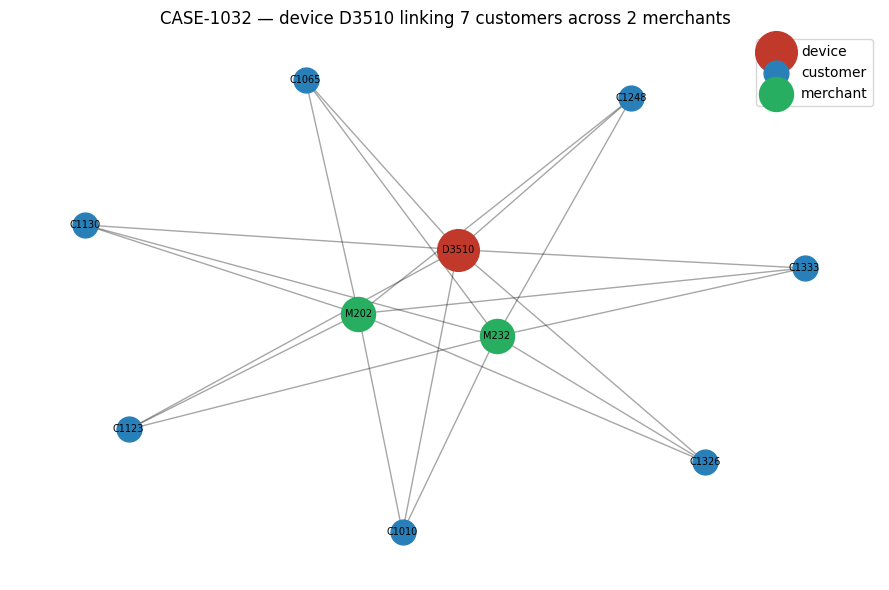

In [ ]:
top_case = cases.iloc[0]
grp = alerts[alerts["device_id"] == top_case["pivot_device"]]

sub = nx.Graph()
dev = str(top_case["pivot_device"])
sub.add_node(dev, kind="device")
for c in grp["customer_id"].unique():
    sub.add_node(str(c), kind="customer"); sub.add_edge(str(c), dev)
for m in grp["merchant_id"].unique():
    sub.add_node(str(m), kind="merchant")
    for c in grp[grp["merchant_id"] == m]["customer_id"].unique():
        sub.add_edge(str(c), str(m))

colour = {"device":"#c0392b","customer":"#2980b9","merchant":"#27ae60"}
sizes  = {"device":900,"customer":320,"merchant":600}
pos = nx.spring_layout(sub, seed=SEED, k=0.7)

plt.figure(figsize=(9,6))
nx.draw_networkx_edges(sub, pos, alpha=0.35)
for kind in colour:
    nodes = [n for n,d in sub.nodes(data=True) if d["kind"] == kind]
    nx.draw_networkx_nodes(sub, pos, nodelist=nodes, node_color=colour[kind],
                           node_size=sizes[kind], label=kind)
nx.draw_networkx_labels(sub, pos, font_size=7)
plt.title(f"{top_case['case_id']} — device {dev} linking "
          f"{top_case['customers']} customers across {top_case['merchants']} merchants")
plt.legend(scatterpoints=1); plt.axis("off"); plt.tight_layout(); plt.show()

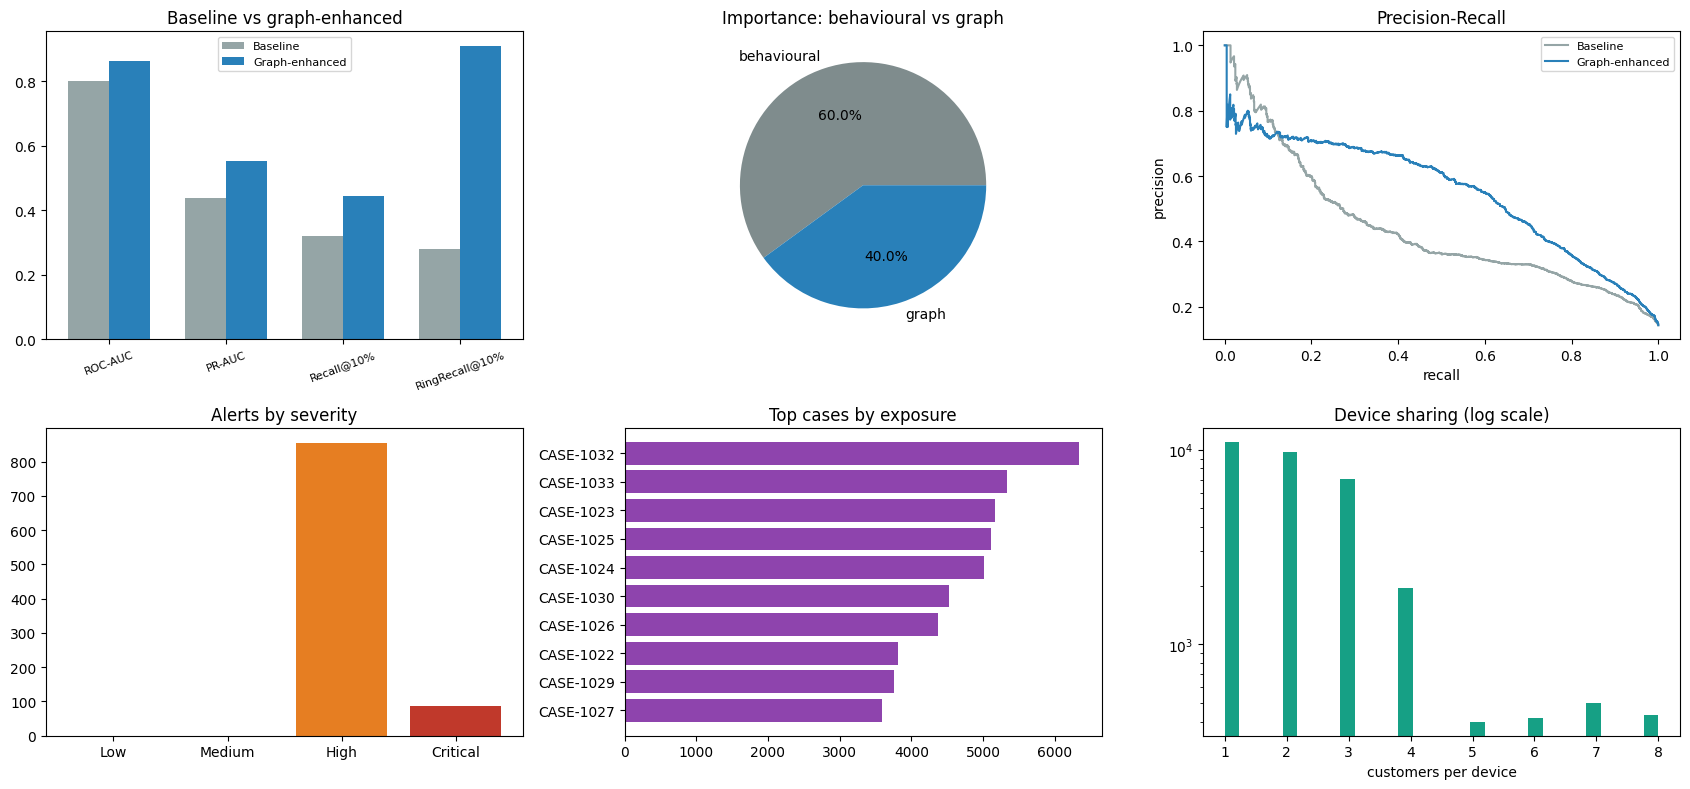

2026-09-18 18:31:01,600 | INFO | Rendered investigation dashboard


In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8))

# 1 — headline experiment
m = ["ROC-AUC","PR-AUC","Recall@10%","RingRecall@10%"]
x = np.arange(len(m)); w = 0.35
ax[0,0].bar(x-w/2, [res_base[k] for k in m],  w, label="Baseline",       color="#95a5a6")
ax[0,0].bar(x+w/2, [res_graph[k] for k in m], w, label="Graph-enhanced", color="#2980b9")
ax[0,0].set_xticks(x); ax[0,0].set_xticklabels(m, rotation=20, fontsize=8)
ax[0,0].set_title("Baseline vs graph-enhanced"); ax[0,0].legend(fontsize=8)

# 2 — feature importance by type
byt = imp.groupby("type")["importance"].sum()
ax[0,1].pie(byt.values, labels=byt.index, autopct="%1.1f%%", colors=["#7f8c8d","#2980b9"])
ax[0,1].set_title("Importance: behavioural vs graph")

# 3 — precision-recall curves
for p, lab, col in [(p_base,"Baseline","#95a5a6"), (p_graph,"Graph-enhanced","#2980b9")]:
    pr, rc, _ = precision_recall_curve(test["is_fraud"], p)
    ax[0,2].plot(rc, pr, label=lab, color=col)
ax[0,2].set_xlabel("recall"); ax[0,2].set_ylabel("precision")
ax[0,2].set_title("Precision-Recall"); ax[0,2].legend(fontsize=8)

# 4 — alert severity
sev = alerts["severity"].value_counts().reindex(["Low","Medium","High","Critical"]).fillna(0)
ax[1,0].bar(sev.index, sev.values, color=["#95a5a6","#f39c12","#e67e22","#c0392b"])
ax[1,0].set_title("Alerts by severity")

# 5 — case exposure
top10 = cases.head(10)
ax[1,1].barh(top10["case_id"], top10["exposure"], color="#8e44ad")
ax[1,1].invert_yaxis(); ax[1,1].set_title("Top cases by exposure")

# 6 — device sharing distribution
ax[1,2].hist(f["g_device_shared_customers"], bins=30, color="#16a085")
ax[1,2].set_yscale("log"); ax[1,2].set_xlabel("customers per device")
ax[1,2].set_title("Device sharing (log scale)")

plt.tight_layout(); plt.show()
logger.info("Rendered investigation dashboard")

In [ ]:
print("=== PLATFORM SUMMARY ===")
print(f"Transactions processed   : {len(f):,}")
print(f"Graph nodes / edges      : {G.number_of_nodes():,} / {G.number_of_edges():,}")
print(f"Baseline ROC-AUC         : {res_base['ROC-AUC']:.4f}")
print(f"Graph-enhanced ROC-AUC   : {res_graph['ROC-AUC']:.4f}  ({res_graph['ROC-AUC']-res_base['ROC-AUC']:+.4f})")
print(f"Ring recall @ top-10%    : {res_base['RingRecall@10%']:.3f} -> {res_graph['RingRecall@10%']:.3f}")
print(f"Rings recovered          : {caught}/{top_n}")
print(f"Alerts raised            : {len(alerts):,} (precision {alerts['is_fraud'].mean():.1%})")
print(f"Cases opened             : {len(cases)}")
print("\n=== LAST 10 LOG LINES ===")
print("".join(open("investigation.log").readlines()[-10:]))

=== PLATFORM SUMMARY ===
Transactions processed   : 31,449
Graph nodes / edges      : 972 / 17,765
Baseline ROC-AUC         : 0.8010
Graph-enhanced ROC-AUC   : 0.8618  (+0.0608)
Ring recall @ top-10%    : 0.281 -> 0.909
Rings recovered          : 12/12
Alerts raised            : 944 (precision 64.8%)
Cases opened             : 34

=== LAST 10 LOG LINES ===
2026-09-18 18:30:05,107 | INFO | Investigation platform logging initialised
2026-09-18 18:30:33,036 | INFO | Labelled 31449 transactions | fraud rate 0.169
2026-09-18 18:30:34,854 | INFO | Graph built: 972 nodes, 17765 edges
2026-09-18 18:30:46,251 | INFO | baseline: ROC-AUC=0.8010 PR-AUC=0.4369 Recall@10%=0.3206 RingRecall@10%=0.2808
2026-09-18 18:30:57,146 | INFO | graph-enhanced: ROC-AUC=0.8618 PR-AUC=0.5512 Recall@10%=0.4429 RingRecall@10%=0.9093
2026-09-18 18:30:57,293 | INFO | Ring detection: 12/12 seeded rings recovered
2026-09-18 18:30:57,340 | INFO | 944 alerts raised | precision 0.648
2026-09-18 18:30:57,404 | INFO | Opened